<a href="https://colab.research.google.com/github/cengesser/AI-101-Assignment--1/blob/main/assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training set size: 1903 samples
Testing set size: 476 samples

Linear Regression Model Trained.

Model Evaluation on Test Set:
Mean Squared Error (MSE): 10303.28
R-squared (R2) Score: 0.87

Model Coefficients:
revenue: 0.00
profit_margin: 605.98
profit: -0.00
pe_ratio: 82.32
debt_to_equity: -1.30
dividend_yield: -143.66
market_cap: 0.00
Intercept: -218.20


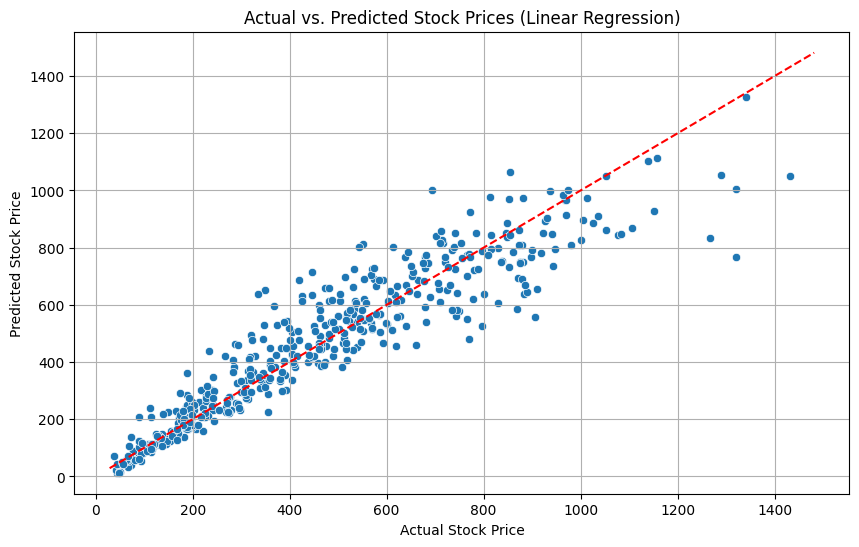

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Assuming df is already defined from the previous cell and cleaned (NaNs dropped)

# 1. Define Features (X) and Target (y)
# Selecting numerical features relevant to stock price prediction
X = df[['revenue', 'profit_margin', 'profit', 'pe_ratio', 'debt_to_equity', 'dividend_yield', 'market_cap']]
y = df['stock_price']

# 2. Split Data into Training and Testing Sets
# Using 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# 3. Initialize and Train the Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

print("\nLinear Regression Model Trained.")

# 4. Make Predictions on the Test Set
y_pred = model.predict(X_test)

# 5. Evaluate the Model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Evaluation on Test Set:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")

# Optional: Display coefficients and intercept
print("\nModel Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.2f}")
print(f"Intercept: {model.intercept_:.2f}")

# Optional: Visualize Predictions vs Actuals
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Stock Price")
plt.ylabel("Predicted Stock Price")
plt.title("Actual vs. Predicted Stock Prices (Linear Regression)")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--') # Red dashed line for ideal prediction
plt.grid(True)
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

file_path = '/content/finance_data.csv'  # Updated to the correct local path
try:
    df = pd.read_csv(file_path)
    print("File loaded successfully!")
    display(df.head())
except FileNotFoundError:
    print(f"File not found at {file_path}. Please check the path and try again.")
except Exception as e:
    print(f"An error occurred: {e}")

File loaded successfully!


,year,quarter,company_id,sector,revenue,profit_margin,profit,stock_price,pe_ratio,debt_to_equity,dividend_yield,market_cap
0,2000,1,Company_1,Finance,2.198686e+08,0.04,9755484.56,36.15,3.71,1.42,0.01,2.363830e+09
1,2000,1,Company_2,Consumer Goods,3.298028e+08,0.06,18814148.79,54.22,2.88,1.71,0.01,3.956767e+09
2,2000,1,Company_3,Finance,4.397371e+08,0.07,30660094.32,72.29,2.36,1.66,0.03,3.633502e+09
3,2000,1,Company_4,Energy,5.496714e+08,0.08,45293321.16,90.37,2.00,1.07,0.05,3.833839e+09
4,2000,1,Company_5,Manufacturing,6.596057e+08,0.10,62713829.30,108.44,1.73,1.36,0.02,6.178690e+09


In [ ]:
import pandas as pd

# Define the file path to your CSV
file_path = '/content/finance_data.csv' # Updated to the correct local path

try:
    df = pd.read_csv(file_path)
    print("File 'finance_data.csv' loaded successfully!")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure the path is correct.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

File 'finance_data.csv' loaded successfully!


,year,quarter,company_id,sector,revenue,profit_margin,profit,stock_price,pe_ratio,debt_to_equity,dividend_yield,market_cap
0,2000,1,Company_1,Finance,2.198686e+08,0.04,9755484.56,36.15,3.71,1.42,0.01,2.363830e+09
1,2000,1,Company_2,Consumer Goods,3.298028e+08,0.06,18814148.79,54.22,2.88,1.71,0.01,3.956767e+09
2,2000,1,Company_3,Finance,4.397371e+08,0.07,30660094.32,72.29,2.36,1.66,0.03,3.633502e+09
3,2000,1,Company_4,Energy,5.496714e+08,0.08,45293321.16,90.37,2.00,1.07,0.05,3.833839e+09
4,2000,1,Company_5,Manufacturing,6.596057e+08,0.10,62713829.30,108.44,1.73,1.36,0.02,6.178690e+09


In [ ]:
print("\n--- DataFrame Info ---\n")
df.info()

print("\n--- DataFrame Description (Numerical Columns) ---\n")
display(df.describe())

print(f"\n--- DataFrame Shape (Rows, Columns) ---\n{df.shape}")

print("\n--- DataFrame Columns ---\n")
print(df.columns.tolist())


--- DataFrame Info ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            2500 non-null   int64  
 1   quarter         2500 non-null   int64  
 2   company_id      2500 non-null   object 
 3   sector          2500 non-null   object 
 4   revenue         2500 non-null   float64
 5   profit_margin   2500 non-null   float64
 6   profit          2500 non-null   float64
 7   stock_price     2500 non-null   float64
 8   pe_ratio        2500 non-null   float64
 9   debt_to_equity  2379 non-null   float64
 10  dividend_yield  2500 non-null   float64
 11  market_cap      2500 non-null   float64
dtypes: float64(8), int64(2), object(2)
memory usage: 234.5+ KB

--- DataFrame Description (Numerical Columns) ---



,year,quarter,revenue,profit_margin,profit,stock_price,pe_ratio,debt_to_equity,dividend_yield,market_cap
count,2500.000000,2500.000000,2.500000e+03,2500.000000,2.500000e+03,2500.000000,2500.000000,2379.000000,2500.000000,2.500000e+03
mean,2012.000000,2.500000,2.658120e+09,0.373936,1.199423e+09,465.459628,0.741324,1.193817,0.020316,2.526694e+10
std,7.212545,1.118258,1.624470e+09,0.221228,1.129004e+09,283.374544,0.632146,0.403104,0.010457,2.104715e+10
min,2000.000000,1.000000,1.727128e+08,0.030000,7.817187e+06,28.840000,0.110000,0.000000,-0.010000,5.519471e+08
25%,2006.000000,1.750000,1.329516e+09,0.200000,2.821963e+08,230.660000,0.340000,0.920000,0.010000,9.483218e+09
50%,2012.000000,2.500000,2.409744e+09,0.340000,8.637113e+08,425.275000,0.530000,1.200000,0.020000,1.888935e+10
75%,2018.000000,3.250000,3.729541e+09,0.510000,1.803392e+09,650.585000,0.900000,1.460000,0.030000,3.583691e+10
max,2024.000000,4.000000,8.114111e+09,1.330000,6.382023e+09,1481.760000,6.260000,2.440000,0.050000,1.273142e+11



--- DataFrame Shape (Rows, Columns) ---
(2500, 12)

--- DataFrame Columns ---

['year', 'quarter', 'company_id', 'sector', 'revenue', 'profit_margin', 'profit', 'stock_price', 'pe_ratio', 'debt_to_equity', 'dividend_yield', 'market_cap']


In [ ]:
initial_rows = df.shape[0]
df.dropna(inplace=True)
print(f"Number of rows before dropping NaNs: {initial_rows}")
print(f"Number of rows after dropping NaNs: {df.shape[0]}")

Number of rows before dropping NaNs: 2500
Number of rows after dropping NaNs: 2379


In [ ]:
print("\n--- Missing values after dropping rows ---\n")
display(df.isnull().sum())


--- Missing values after dropping rows ---



,0
year,0
quarter,0
company_id,0
sector,0
revenue,0
profit_margin,0
profit,0
stock_price,0
pe_ratio,0
debt_to_equity,0


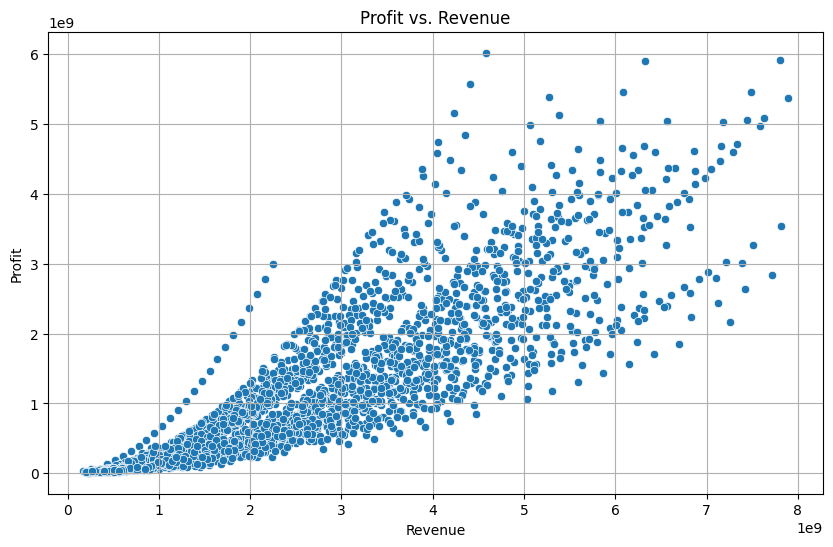

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of Profit vs. Revenue
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='revenue', y='profit')
plt.title('Profit vs. Revenue')
plt.xlabel('Revenue')
plt.ylabel('Profit')
plt.grid(True)
plt.show()

Generating correlation heatmap of numerical columns...


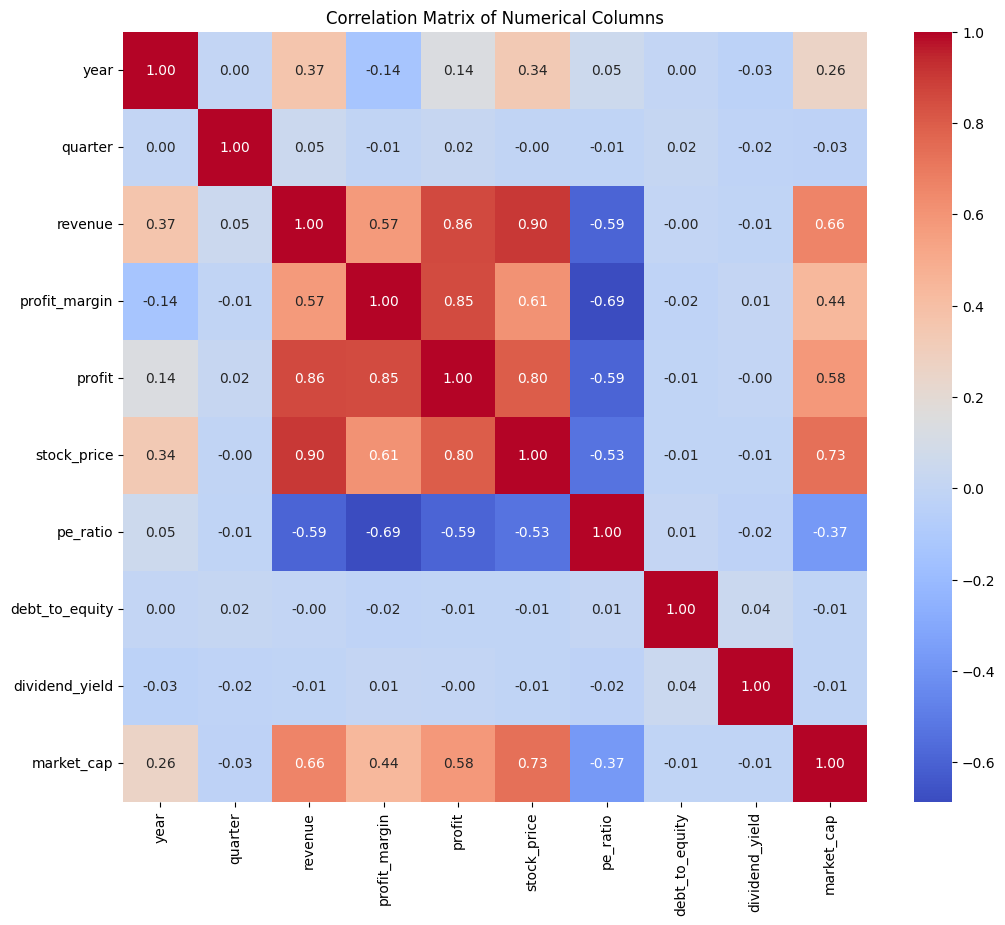

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check if df is defined
if 'df' in locals() and isinstance(df, pd.DataFrame):
    print("Generating correlation heatmap of numerical columns...")
    # Select only numerical columns for correlation calculation
    numerical_df = df.select_dtypes(include=['number'])

    if not numerical_df.empty:
        correlation_matrix = numerical_df.corr()
        plt.figure(figsize=(12, 10))
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
        plt.title('Correlation Matrix of Numerical Columns')
        plt.show()
    else:
        print("No numerical columns found in the DataFrame to visualize correlations.")
else:
    print("Error: DataFrame 'df' is not loaded. Please ensure 'finance_data.csv' is correctly loaded and try again.")

In [ ]:
import pandas as pd

# Check if df is defined and is a DataFrame
if 'df' in locals() and isinstance(df, pd.DataFrame):
    print("Identifying highly correlated columns...")

    # Select only numerical columns for correlation calculation
    numerical_df = df.select_dtypes(include=['number'])

    if not numerical_df.empty:
        correlation_matrix = numerical_df.corr().abs()

        # Set a correlation threshold (e.g., 0.7 for high correlation)
        threshold = 0.7

        # Find pairs of columns with correlation above the threshold
        high_corr_pairs = []
        for i in range(len(correlation_matrix.columns)):
            for j in range(i + 1, len(correlation_matrix.columns)):
                col1 = correlation_matrix.columns[i]
                col2 = correlation_matrix.columns[j]
                if correlation_matrix.loc[col1, col2] >= threshold:
                    high_corr_pairs.append((col1, col2, correlation_matrix.loc[col1, col2]))

        if high_corr_pairs:
            print(f"\nColumns with absolute correlation >= {threshold}:")
            for col1, col2, corr_value in high_corr_pairs:
                print(f"- {col1} and {col2}: {corr_value:.2f}")
        else:
            print(f"No column pairs found with absolute correlation >= {threshold}.")
    else:
        print("No numerical columns found in the DataFrame to check correlations.")
else:
    print("Error: DataFrame 'df' is not loaded. Please ensure 'finance_data.csv' is correctly loaded and try again.")

Identifying highly correlated columns...

Columns with absolute correlation >= 0.7:
- revenue and profit: 0.86
- revenue and stock_price: 0.90
- profit_margin and profit: 0.85
- profit and stock_price: 0.80
- stock_price and market_cap: 0.73


In [ ]:
import numpy as np
import pandas as pd

# Generate 100 random data points
n_samples = 100

# Generate random features (e.g., related to financial metrics)
np.random.seed(42) # for reproducibility
feature_1 = np.random.rand(n_samples) * 100 # e.g., company revenue
feature_2 = np.random.rand(n_samples) * 50  # e.g., market sentiment score
feature_3 = np.random.rand(n_samples) * 20  # e.g., economic indicator

# Generate a 'stock_price' target variable with some linear dependency on features and noise
# stock_price = 2 * feature_1 + 1.5 * feature_2 - 0.8 * feature_3 + bias + noise
stock_price = 2 * feature_1 + 1.5 * feature_2 - 0.8 * feature_3 + 50 + np.random.randn(n_samples) * 10

# Create a DataFrame
test_df = pd.DataFrame({
    'feature_1': feature_1,
    'feature_2': feature_2,
    'feature_3': feature_3,
    'stock_price': stock_price
})

print(f"Generated {n_samples} random data points for model testing:")
display(test_df.head())

In [ ]:
import numpy as np
import pandas as pd

# Generate 100 random data points
n_samples = 100
np.random.seed(42) # for reproducibility

# Define target orders of magnitude for each feature and the target variable.
# These are educated guesses for typical financial data and can be adjusted.

# Feature 1: e.g., Annual Revenue (in millions)
# Let's generate values roughly between 10 million and 100 million
feature_1_min = 10_000_000
feature_1_max = 100_000_000
feature_1 = np.random.uniform(feature_1_min, feature_1_max, n_samples)

# Feature 2: e.g., Profit Margin (as a percentage, 5% to 30%)
feature_2_min = 0.05
feature_2_max = 0.30
feature_2 = np.random.uniform(feature_2_min, feature_2_max, n_samples)

# Feature 3: e.g., Price-to-Earnings (P/E) Ratio
feature_3_min = 10
feature_3_max = 50
feature_3 = np.random.uniform(feature_3_min, feature_3_max, n_samples)

# Stock Price: Target variable, influenced by features with appropriate scaling.
# Aim for stock prices generally between 100 and 1000.
# Coefficients and base_price are tuned to get stock_price in the target range.
# Scaling feature_1 down by 1M to represent 'revenue in millions' for the linear model.
# Scaling feature_2 up by 100 to represent 'profit margin percentage' for the linear model.
coeff_1 = 0.5   # Revenue (in millions) has a positive impact on stock price
coeff_2 = 5     # Profit Margin (percentage) has a positive impact
coeff_3 = -2    # P/E Ratio (could have negative correlation if too high, or positive if market values growth)
base_price = 200 # Base stock price
noise_std = 20 # Standard deviation of noise

stock_price = (coeff_1 * (feature_1 / 1_000_000)) + (coeff_2 * (feature_2 * 100)) + (coeff_3 * feature_3) + base_price + np.random.randn(n_samples) * noise_std

# Ensure stock price doesn't go below a reasonable minimum (e.g., $1)
stock_price[stock_price < 1] = 1

# Create a DataFrame
test_df = pd.DataFrame({
    'feature_1': feature_1, # Example: Revenue (millions)
    'feature_2': feature_2, # Example: Profit Margin (decimal)
    'feature_3': feature_3, # Example: P/E Ratio
    'stock_price': stock_price
})

print(f"Generated {n_samples} random data points for model testing with adjusted magnitudes:")
display(test_df.head())
print("\nDescriptive statistics for the generated data:")
display(test_df.describe())

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score

# Assuming 'model', 'X', and 'y' (from test_df) are available from previous cells.

# 1. Predict stock price for the entire generated dataset
# X contains the features for all 100 samples of test_df
y_pred_full = model.predict(X)

print("Predicted Stock Prices vs. Actual Stock Prices (for all generated data):\n")

# Create a DataFrame to easily compare actual vs. predicted values for the first few samples
comparison_df = pd.DataFrame({'Actual Stock Price': y, 'Predicted Stock Price': y_pred_full})
display(comparison_df.head())

# 2. Visualize the predicted stock price against the actual stock price
plt.figure(figsize=(12, 7))
sns.scatterplot(x=y, y=y_pred_full)
plt.xlabel("Actual Stock Price (All Data)")
plt.ylabel("Predicted Stock Price (All Data)")
plt.title("Actual vs. Predicted Stock Prices (Linear Regression on All Generated Data)")
# Add a line for perfect prediction (y=x)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Perfect Prediction')
plt.legend()
plt.grid(True)
plt.show()

# Alternative visualization: Plot actual and predicted values over sample index
plt.figure(figsize=(15, 7))
plt.plot(comparison_df.index, comparison_df['Actual Stock Price'], label='Actual Stock Price', marker='o', markersize=4, linestyle='-', alpha=0.7)
plt.plot(comparison_df.index, comparison_df['Predicted Stock Price'], label='Predicted Stock Price', marker='x', markersize=4, linestyle='--', alpha=0.7)
plt.title('Actual vs. Predicted Stock Prices Over Sample Index (All Generated Data)')
plt.xlabel('Sample Index')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Reiterate the limitation regarding the 'original dataset'
print("\nNote: A direct comparison against the 'original dataset' (finance_data.csv) is not possible as it was not successfully loaded due to 'FileNotFoundError'. The comparison above is against the actual values within the synthetic 'test_df'.")

# Optionally, also report the overall MSE and R2 for the full dataset
full_mse = mean_squared_error(y, y_pred_full)
full_r2 = r2_score(y, y_pred_full)
print(f"\nOverall Mean Squared Error (Full Generated Dataset): {full_mse:.2f}")
print(f"Overall R-squared (Full Generated Dataset): {full_r2:.2f}")